# Master INFO - Mini projet
## Évaluation de modèles d'embeddings de topic

**Année 2026**

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

from embeddingTopicEvaluatorLib.metrics.diversity import diversity
from embeddingTopicEvaluatorLib.metrics.coherence import coherence
from embeddingTopicEvaluatorLib.metrics.retrieval import retrieval
from embeddingTopicEvaluatorLib.metrics.cohesion import cohesion
from embeddingTopicEvaluatorLib.config.config import settings
from embeddingTopicEvaluatorLib.models.bertopic_wrapper import TopicModelEvaluatorBERTopic

/info/etu/m2/s2101052/miniconda3/envs/ETE/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-12 13:29:37.622756: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 13:29:37.677713: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 13:29:40.335298: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. Y

## Dataset

In [2]:
from datasets import load_dataset
db = load_dataset("jinaai/big-patent-clustering", split="test")
docs = db["sentences"][0]

## Config

In [3]:
config = settings.BERTOPIC_CONFIG_HDBSCAN

In [4]:
nr_topics_param = np.linspace(2, 11, 10, dtype=int)

## Train

In [5]:
def generate_bertopic_models(param, base_config):
    """
    Génère une liste de modèles d'évaluation BERTopic en faisant varier 
    le paramètre voulu.
    """
    topic_models = []
    
    # On itère sur chaque paramètre défini dans la liste
    for param in param:
        
        # Copie profonde pour éviter de modifier la configuration des modèles précédents
        current_config = copy.deepcopy(base_config)
        
        # Mise à jour du nombre de topics dans la configuration courante
        current_config["BERTopic"]["nr_topics"] = int(param)
        
        # Création de l'évaluateur avec la configuration spécifique et ajout à la liste
        model_evaluator = TopicModelEvaluatorBERTopic(current_config)
        topic_models.append(model_evaluator)
        
    return topic_models

In [6]:
# Test en faisant varié le paramètre nombre de topics
topic_models = generate_bertopic_models(nr_topics_param, config)

In [7]:
def evaluate_all_models(topic_models, docs):
    """
    Évalue une liste de modèles BERTopic sur un corpus de documents
    """
    topics_hdbscans = []
    probs_hdbscans = []

    # On parcourt chaque modèle généré précédemment
    for model in topic_models:
        
        # On lance l'évaluation du modèle sur le corpus
        # La méthode evaluate retourne les topics et leurs probabilités
        topics_hdbscan, probs_hdbscan = model.evaluate(docs)
        
        # Ajout des résultats récupérés dans nos listes
        topics_hdbscans.append(topics_hdbscan)
        probs_hdbscans.append(probs_hdbscan)
        
    return topics_hdbscans, probs_hdbscans

In [8]:
topics_hdbscans, probs_hdbscans = evaluate_all_models(topic_models, docs)

2026-03-12 13:29:57,599 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 782/782 [04:46<00:00,  2.73it/s]
2026-03-12 13:35:14,179 - BERTopic - Embedding - Completed ✓
2026-03-12 13:35:14,181 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-12 13:35:39,755 - BERTopic - Dimensionality - Completed ✓
2026-03-12 13:35:39,757 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-12 13:35:42,279 - BERTopic - Cluster - Completed ✓
2026-03-12 13:35:42,281 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-12 13:36:43,305 - BERTopic - Representation - Completed ✓
2026-03-12 13:36:43,319 - BERTopic - Topic reduction - Reducing number of topics
2026-03-12 13:36:43,340 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-12 13:37:48,346 - BERTopic - Representation - Completed ✓
2026-03-12 13:37:48,366 - BERTopic - Topic reduction - Re

## Evaluation

In [9]:
def compute_model_metrics(topic_models, docs):
    """
    Calcule les métriques de cohérence, de recherche (retrieval) et de diversité 
    pour une liste de modèles de topics.
    """
    coherences = []
    retrievals = []
    diversities = []
    cohesions = []

    # On évalue les métriques pour chaque modèle
    for model in topic_models:
        
        # Calcul de la Cohérence
        coherence_stack = coherence(model)
        # On exclut le topic -1 (qui représente le bruit/outliers dans BERTopic)
        valeurs_sans_outliers = [valeur for cle, valeur in coherence_stack.items() if cle != -1]
        # On calcule la moyenne des cohérences des topics "valides"
        coherence_mean = np.mean(valeurs_sans_outliers)
        coherences.append(coherence_mean)

        # Calcul du Retrieval
        # Nécessite le modèle et les documents pour évaluer la pertinence
        retrieval_stack = retrieval(model, docs)
        retrievals.append(retrieval_stack)
        
        # Calcul de la Diversité
        diversity_stack = diversity(model)
        diversities.append(diversity_stack)

        # Calcul de la cohésion
        cohesion_stack = cohesion(model)
        # On calcule la moyenne des cohésions des topics
        cohesion_mean = np.mean(cohesion_stack)
        cohesions.append(cohesion_mean)
        

    return coherences, retrievals, diversities, cohesions

In [11]:
coherences, retrievals, diversitie, cohesions = compute_model_metrics(topic_models, docs)

## Analyse

In [12]:
def graph(param, metric, title, xlabel, ylabel, label, save_name):
    fig = plt.figure(figsize=(10, 6))

    plt.plot(param, metric, marker='o', linestyle='-', color='b', label=label)
    
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    plt.xticks(np.arange(0, 11, 1))
    
    plt.legend()
    plt.show()
    fig.savefig(save_name)

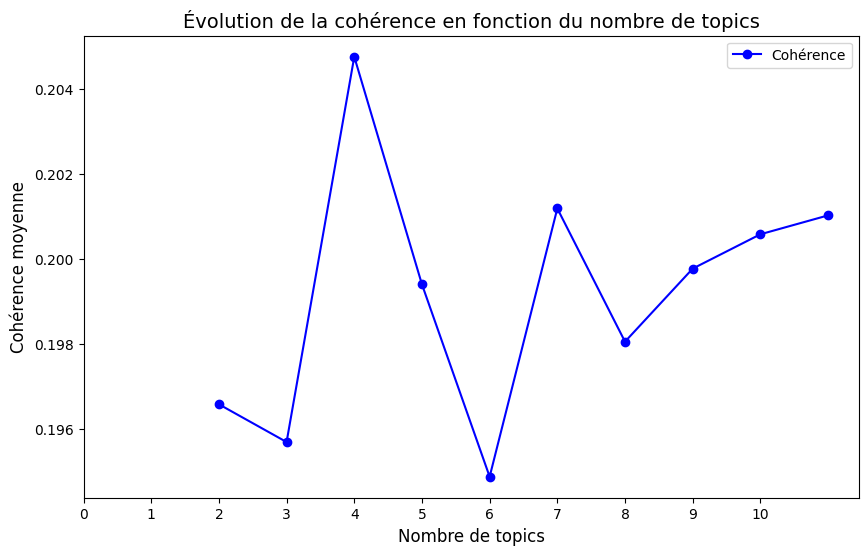

In [13]:
title = 'Évolution de la cohérence en fonction du nombre de topics'
xlabel = 'Nombre de topics'
ylabel = 'Cohérence moyenne'
label = 'Cohérence'
save_name = 'img/Coherence.png'
graph(nr_topics_param, coherences, title, xlabel, ylabel, label, save_name)

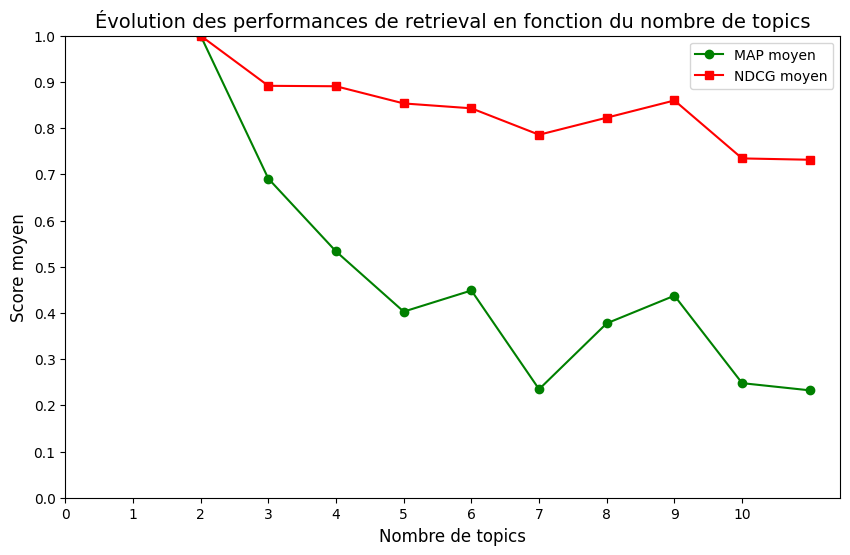

In [14]:
mean_maps = [np.mean([val['map'] for val in res.values()]) for res in retrievals]
mean_ndcgs = [np.mean([val['ndcg'] for val in res.values()]) for res in retrievals]

fig = plt.figure(figsize=(10, 6))

plt.plot(nr_topics_param, mean_maps, marker='o', linestyle='-', color='g', label='MAP moyen')
plt.plot(nr_topics_param, mean_ndcgs, marker='s', linestyle='-', color='r', label='NDCG moyen')

plt.title("Évolution des performances de retrieval en fonction du nombre de topics", fontsize=14)
plt.xlabel("Nombre de topics", fontsize=12)
plt.ylabel("Score moyen", fontsize=12)

plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)

plt.xticks(np.arange(0, 11, 1))

plt.legend()
plt.show()

In [15]:
fig.savefig('img/Retrieval.png')

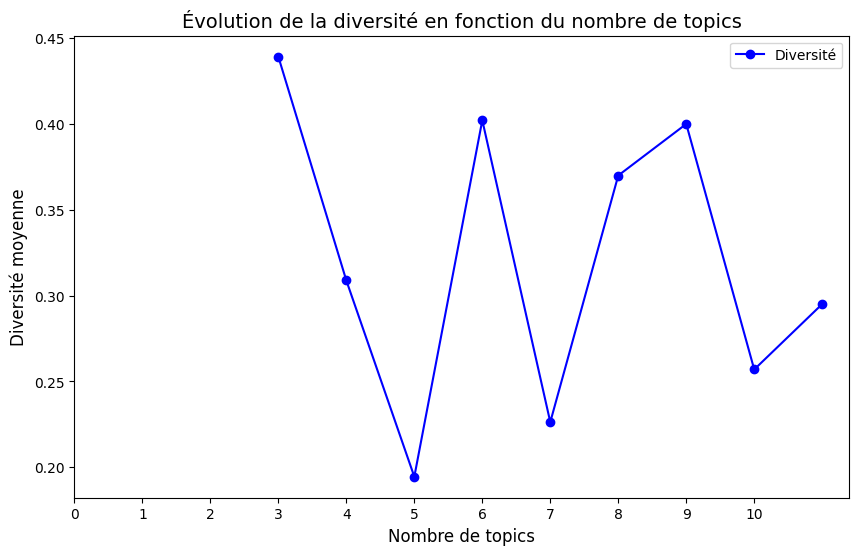

In [17]:
title = 'Évolution de la diversité en fonction du nombre de topics'
xlabel = 'Nombre de topics'
ylabel = 'Diversité moyenne'
label = 'Diversité'
save_name = 'img/Diversite.png'
graph(nr_topics_param, diversitie, title, xlabel, ylabel, label, save_name)

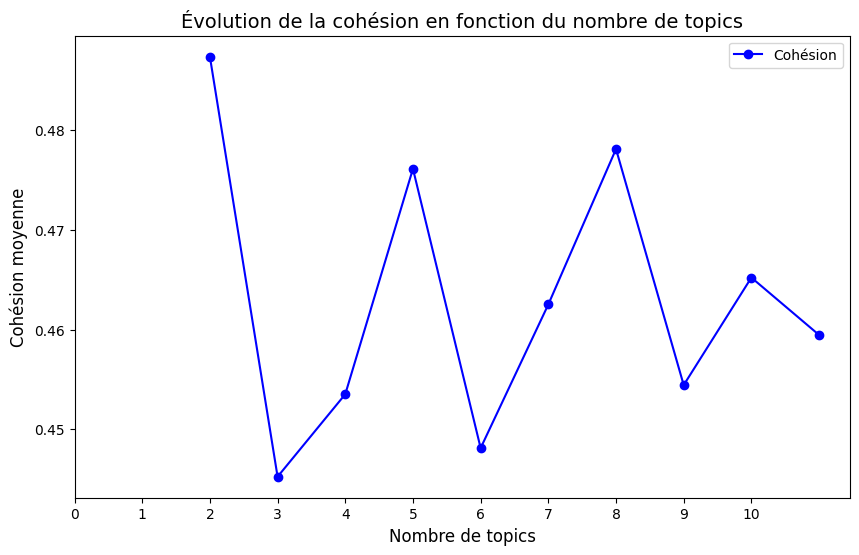

In [18]:
title = 'Évolution de la cohésion en fonction du nombre de topics'
xlabel = 'Nombre de topics'
ylabel = 'Cohésion moyenne'
label = 'Cohésion'
save_name = 'img/Cohesion.png'
graph(nr_topics_param, cohesions, title, xlabel, ylabel, label, save_name)